# 5.143 kilogramos. ¿Eso es mucho?

En 2018, toda la industria del planeta emitió 5.143 kg de contaminantes orgánicos clorados y bromados (Cl/BrPAHs). Suena poco — hasta que descubres que **una sola industria es responsable del 86%**.

---

📄 **Paper:** Yang, Y. et al. (2025). *Global industrial emissions of chlorinated and brominated polycyclic aromatic hydrocarbons.* Nature Sustainability.
DOI: [10.1038/s41893-025-01656-z](https://doi.org/10.1038/s41893-025-01656-z)

🎬 **Video:** [Ver en YouTube](https://youtube.com/shorts/O4Pnh_ESM1M)

[![Abrir en Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ciencia-a-Mordiscos/lab/blob/main/papers/2026-01-17-industria-86-contaminantes-emergentes/notebook.ipynb)

## ¿Qué son los Cl/BrPAHs?

Los hidrocarburos aromáticos policíclicos clorados y bromados (Cl/BrPAHs) son contaminantes orgánicos emergentes. Aparecen cuando procesos industriales a altas temperaturas combinan carbono con cloro o bromo. Son persistentes, tóxicos y se acumulan en los tejidos de organismos vivos (bioacumulación) — igual que sus primos más conocidos, las dioxinas.

El problema: hasta ahora nadie había cuantificado cuánto emite cada sector industrial a nivel global. Lo que hicieron: cruzaron datos de emisión con modelos de machine learning (XGBoost) para estimar cuánto emite cada sector industrial en 184 países.

In [1]:
# ══════════════════════════════════════════════════════════════
# Configuración — modifica estos valores para explorar
# ══════════════════════════════════════════════════════════════
TOTAL_GLOBAL_KG = 5143          # Emisión global estimada (kg, 2018)
N_PAISES = 184                  # Países analizados
N_SECTORES = 11                 # Sectores en el paper (8 con desglose individual en datos)
FUENTE = 'Fuente: Yang et al. (2025), Nature Sustainability | Datos: Zenodo'
COLOR_DATOS = '#2563EB'
COLOR_ALERTA = '#DC2626'
COLOR_SECUNDARIO = '#059669'
COLOR_REFERENCIA = '#D97706'
COLOR_VIOLETA = '#7C3AED'
COLOR_GRIS = '#BBBBBB'

# ══════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, urllib.request

# Estilo CaM
style_file = '../../cam.mplstyle'
if not os.path.exists(style_file):
    style_file = '/tmp/cam.mplstyle'
    if not os.path.exists(style_file):
        urllib.request.urlretrieve(
            'https://raw.githubusercontent.com/Ciencia-a-Mordiscos/lab/main/cam.mplstyle',
            style_file)
plt.style.use(style_file)

# Cargar datos
df_sector = pd.read_csv('datos/emisiones_por_sector.csv')
df_pais = pd.read_csv('datos/emisiones_por_pais.csv')
df_cap = pd.read_csv('datos/emisiones_per_capita.csv')
df_ef = pd.read_csv('datos/factores_emision_stack_gas.csv')
df_reg = pd.read_csv('datos/emisiones_regionales.csv')

# Nombres legibles de sectores
SECTOR_NAMES = {
    'IOS': 'Sinterización de\nmineral de hierro',
    'CK': 'Coquerías',
    'SPb': 'Fundición de\nplomo secundario',
    'SAl': 'Fundición de\naluminio secundario',
    'Scu': 'Fundición de\ncobre secundario',
    'HWI': 'Incineración de\nresiduos peligrosos',
    'MWI': 'Incineración de\nresiduos médicos',
    'MSWI': 'Incineración de\nresiduos sólidos urbanos'
}

print(f"Datos cargados: {len(df_sector)} sectores, {len(df_pais)} países")
print(f"Total global: {df_pais['emision_total_kg'].sum():.0f} kg")
print(f"Top emisor: {df_pais.loc[df_pais['emision_total_kg'].idxmax(), 'pais']} ({df_pais['emision_total_kg'].max():.0f} kg)")

Datos cargados: 8 sectores, 184 países
Total global: 5143 kg
Top emisor: Australia (1393 kg)


## Un sector domina todo

Aquí está.

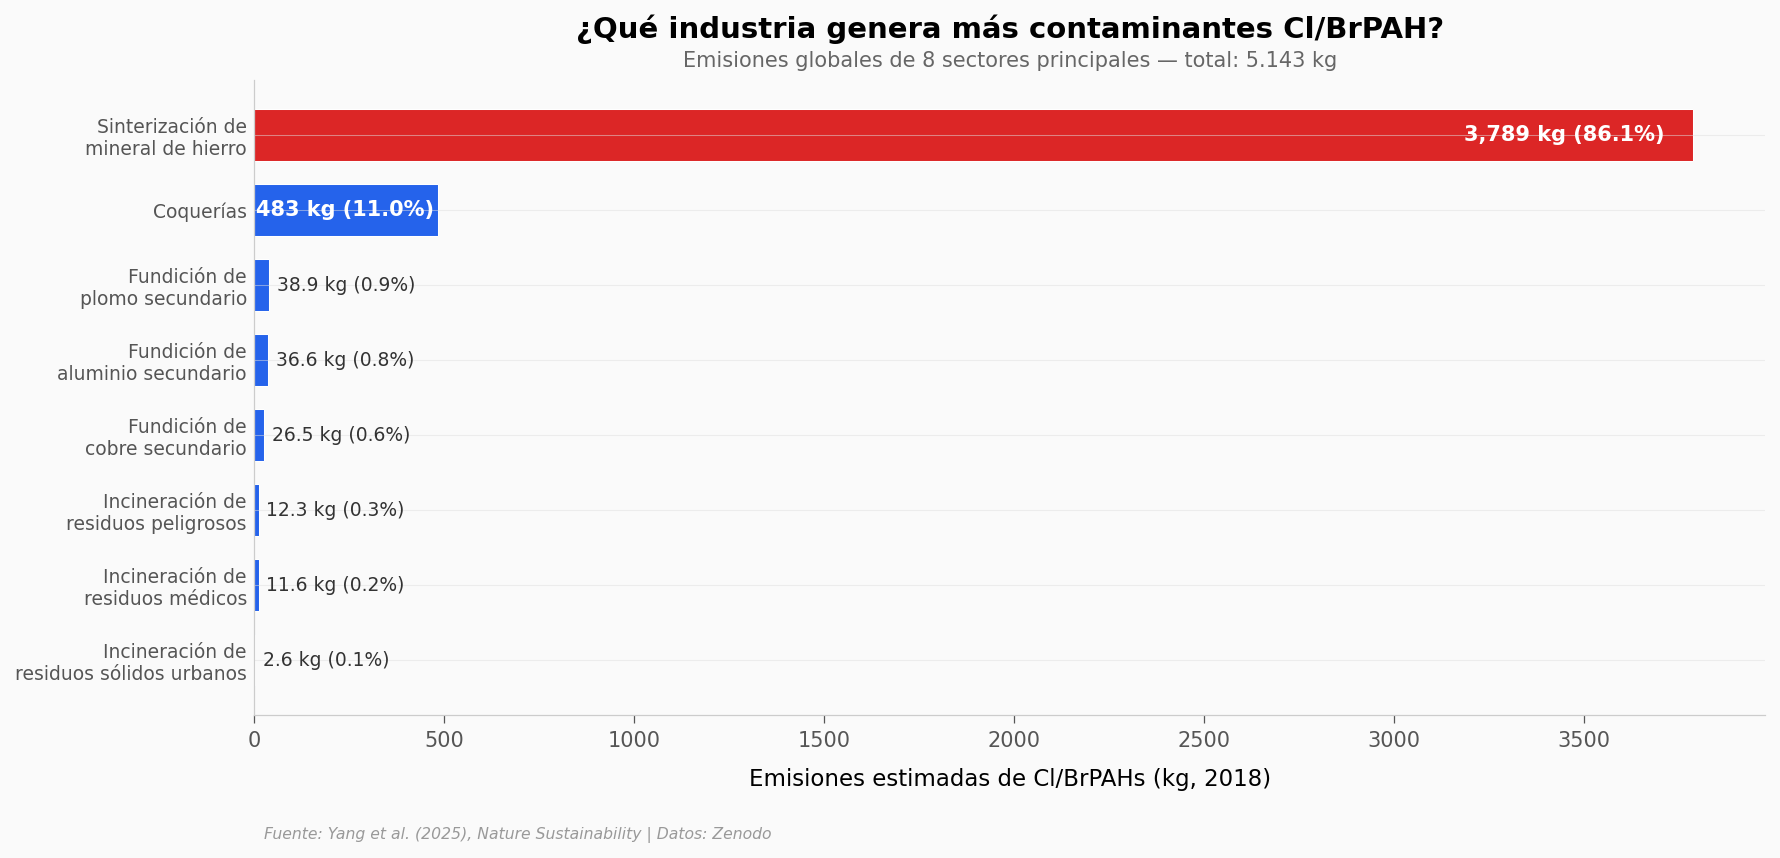

In [2]:
# Gráfica hero: contribución por sector industrial
fig, ax = plt.subplots(figsize=(13, 5.5))

df_plot = df_sector.sort_values('emision_kg', ascending=True)
sectors = [SECTOR_NAMES.get(s, s) for s in df_plot['sector']]
values = df_plot['emision_kg'].values
pcts = df_plot['porcentaje'].values

colors = [COLOR_ALERTA if p > 50 else COLOR_DATOS for p in pcts]

bars = ax.barh(range(len(sectors)), values, color=colors, height=0.7,
               edgecolor='white', linewidth=0.5)

# Inline labels
for i, (val, pct) in enumerate(zip(values, pcts)):
    if val > 100:
        ax.text(val - val * 0.02, i, f'{val:,.0f} kg ({pct}%)',
                ha='right', va='center', fontsize=10, fontweight='bold', color='white')
    else:
        ax.text(val + 20, i, f'{val:,.1f} kg ({pct}%)',
                ha='left', va='center', fontsize=9, color='#333333')

ax.set_yticks(range(len(sectors)))
ax.set_yticklabels(sectors, fontsize=9)
ax.set_xlabel('Emisiones estimadas de Cl/BrPAHs (kg, 2018)', fontsize=11)
ax.set_title('¿Qué industria genera más contaminantes Cl/BrPAH?',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, f'Emisiones globales de 8 sectores principales — total: {TOTAL_GLOBAL_KG:,} kg'.replace(',', '.'),
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.04, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/emisiones_por_sector.png', dpi=200, bbox_inches='tight')
plt.show()

La sinterización de mineral de hierro (IOS, por sus siglas en inglés) emite 3.789 kg de Cl/BrPAHs — el **86,1%** del total global estimado. Las coquerías aportan un 11%. Entre las dos suman el **97,1%**. Los otros 6 sectores con datos disponibles combinados no llegan al 3% (128,4 kg). El paper analiza 11 sectores en total, pero solo 8 tienen desglose individual en los datos publicados.

¿Por qué la sinterización de mineral de hierro contamina tanto? Mezcla mineral de hierro con coque (carbono) y fundentes a ~1.300 °C. Altas temperaturas + cloro en las materias primas + combustión incompleta — las condiciones perfectas para generar Cl/BrPAHs. Y el volumen de producción global de hierro sinterizado es enorme.

> **Nota:** estos valores son estimaciones de un modelo de machine learning (XGBoost), no mediciones directas en chimenea.

## ¿Quién emite más?

Si una sola industria domina, los países con más siderurgia deberían liderar. Veamos.

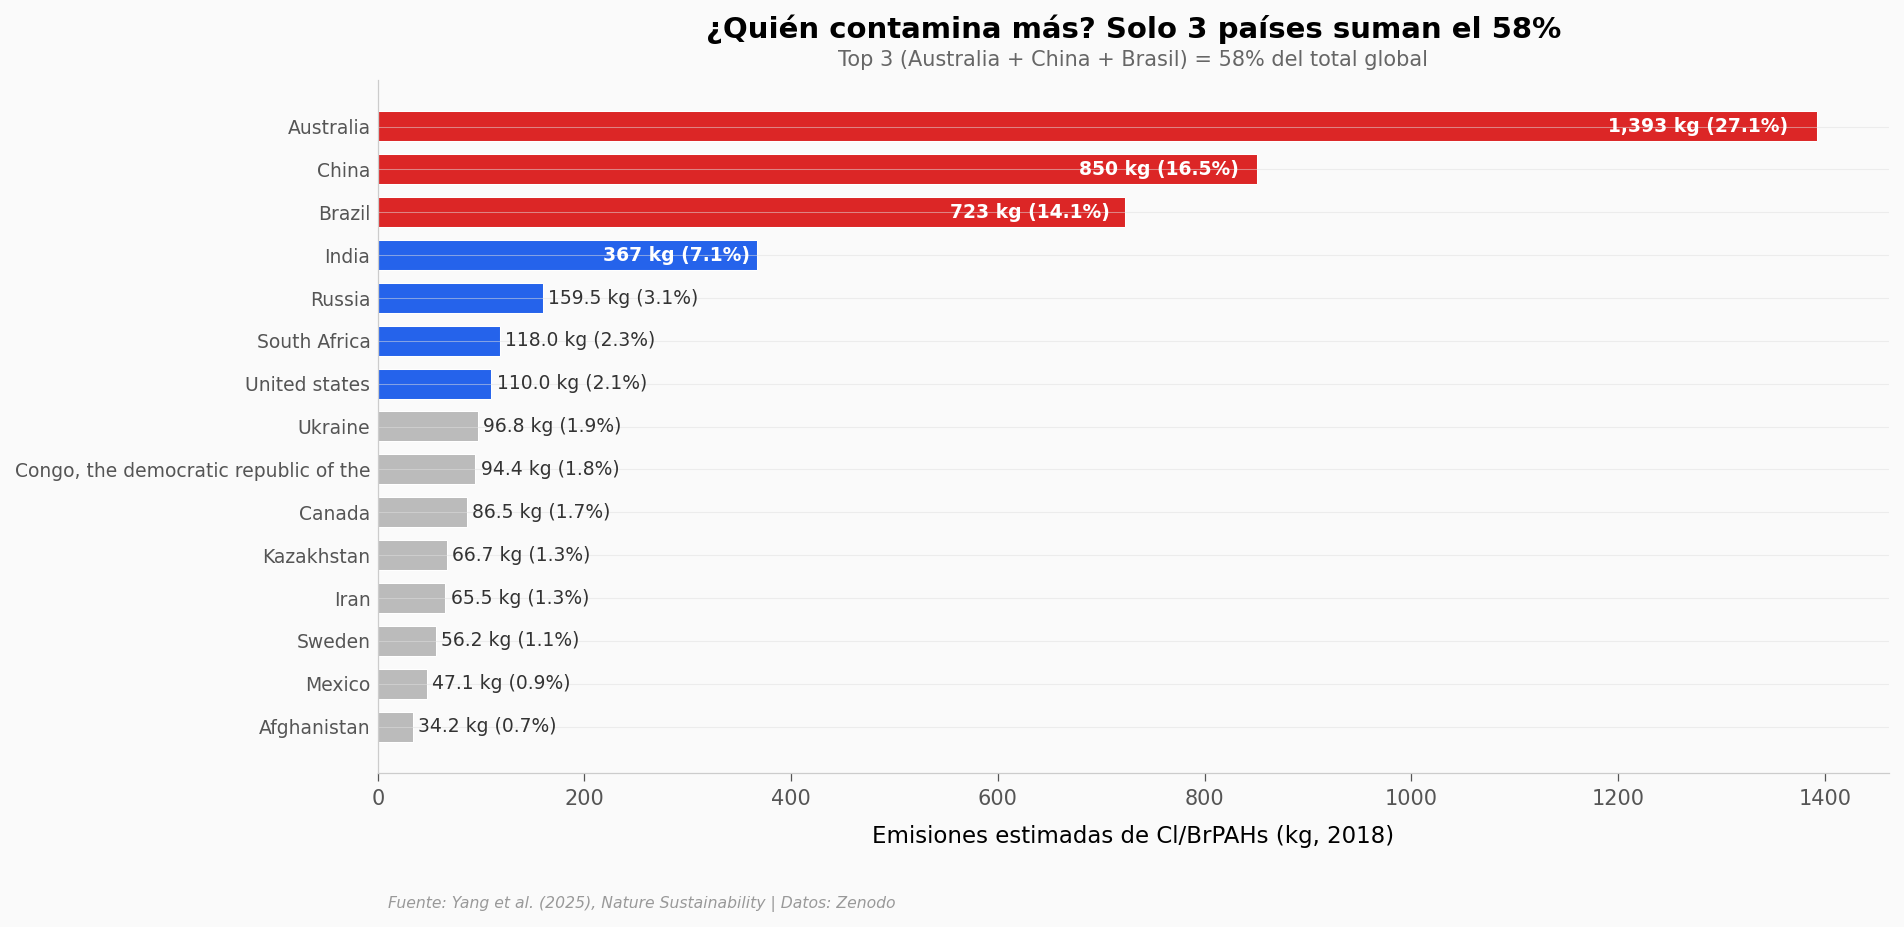

In [3]:
# Top 15 países por emisiones totales
fig, ax = plt.subplots(figsize=(13, 6))

top15 = df_pais.nlargest(15, 'emision_total_kg').sort_values('emision_total_kg', ascending=True)
total = df_pais['emision_total_kg'].sum()

colors = [COLOR_ALERTA if v > 500 else COLOR_DATOS if v > 100 else COLOR_GRIS
          for v in top15['emision_total_kg']]

bars = ax.barh(range(len(top15)), top15['emision_total_kg'].values,
               color=colors, height=0.7, edgecolor='white', linewidth=0.5)

for i, (val, pais) in enumerate(zip(top15['emision_total_kg'].values, top15['pais'].values)):
    pct = val / total * 100
    if val > 200:
        ax.text(val - val * 0.02, i, f'{val:,.0f} kg ({pct:.1f}%)',
                ha='right', va='center', fontsize=9, fontweight='bold', color='white')
    else:
        ax.text(val + 5, i, f'{val:,.1f} kg ({pct:.1f}%)',
                ha='left', va='center', fontsize=9, color='#333333')

ax.set_yticks(range(len(top15)))
ax.set_yticklabels(top15['pais'].values, fontsize=9)
ax.set_xlabel('Emisiones estimadas de Cl/BrPAHs (kg, 2018)', fontsize=11)
ax.set_title('¿Quién contamina más? Solo 3 países suman el 58%',
             fontsize=14, fontweight='bold', pad=20)
top3_sum = top15.nlargest(3, 'emision_total_kg')['emision_total_kg'].sum()
ax.text(0.5, 1.02, f'Top 3 (Australia + China + Brasil) = {top3_sum/total*100:.0f}% del total global',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.04, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/emisiones_por_pais.png', dpi=200, bbox_inches='tight')
plt.show()

Tres países se llevan el 58% de las emisiones estimadas: Australia, China y Brasil. Australia lidera con 1.393 kg, un 64% más que China (850 kg). La razón es directa: Australia es el mayor productor mundial de mineral de hierro sinterizado, y la sinterización genera el 86% de estos contaminantes.

Pero las emisiones totales no cuentan la historia completa. ¿Qué pasa si miramos las emisiones *por persona*?

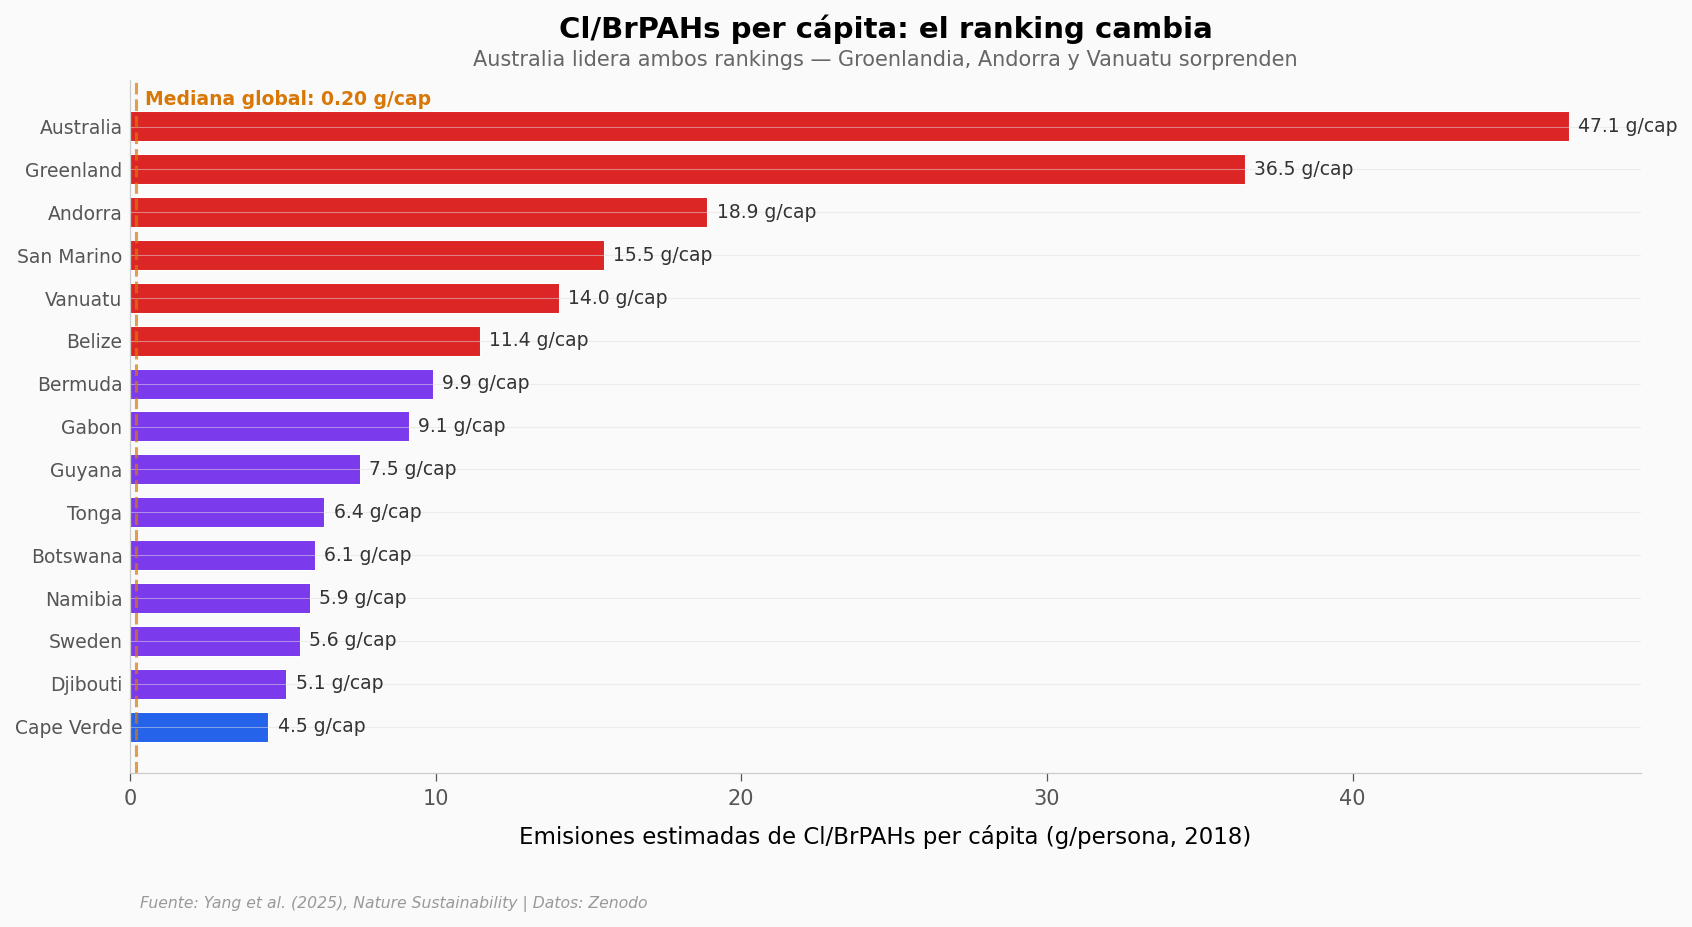

In [4]:
# Top 15 per cápita — el ranking cambia completamente
fig, ax = plt.subplots(figsize=(13, 6))

top15c = df_cap.nlargest(15, 'emision_g_per_capita').sort_values('emision_g_per_capita', ascending=True)

colors_c = [COLOR_ALERTA if v > 10 else COLOR_VIOLETA if v > 5 else COLOR_DATOS
            for v in top15c['emision_g_per_capita']]

bars = ax.barh(range(len(top15c)), top15c['emision_g_per_capita'].values,
               color=colors_c, height=0.7, edgecolor='white', linewidth=0.5)

mediana = df_cap['emision_g_per_capita'].median()
ax.axvline(x=mediana, color=COLOR_REFERENCIA, linewidth=1.5, linestyle='--', alpha=0.7)
ax.text(mediana + 0.3, 14.5, f'Mediana global: {mediana:.2f} g/cap',
        fontsize=9, color=COLOR_REFERENCIA, fontweight='bold')

for i, (val, pais) in enumerate(zip(top15c['emision_g_per_capita'].values, top15c['pais'].values)):
    ax.text(val + 0.3, i, f'{val:.1f} g/cap',
            ha='left', va='center', fontsize=9, color='#333333')

ax.set_yticks(range(len(top15c)))
ax.set_yticklabels([p.title() for p in top15c['pais'].values], fontsize=9)
ax.set_xlabel('Emisiones estimadas de Cl/BrPAHs per cápita (g/persona, 2018)', fontsize=11)
ax.set_title('Cl/BrPAHs per cápita: el ranking cambia',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, 'Australia lidera ambos rankings — Groenlandia, Andorra y Vanuatu sorprenden',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.04, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/emisiones_per_capita.png', dpi=200, bbox_inches='tight')
plt.show()

El per cápita revela algo inesperado: Australia no solo lidera en total — con 47,1 g/persona, está **236 veces por encima de la mediana global** (0,20 g/cap). Pero aparecen sorpresas: Groenlandia, Andorra, Vanuatu. ¿Por qué? Son países pequeños donde una sola planta siderúrgica o metalúrgica sesga el per cápita.

## ¿Qué tan desigual es la distribución?

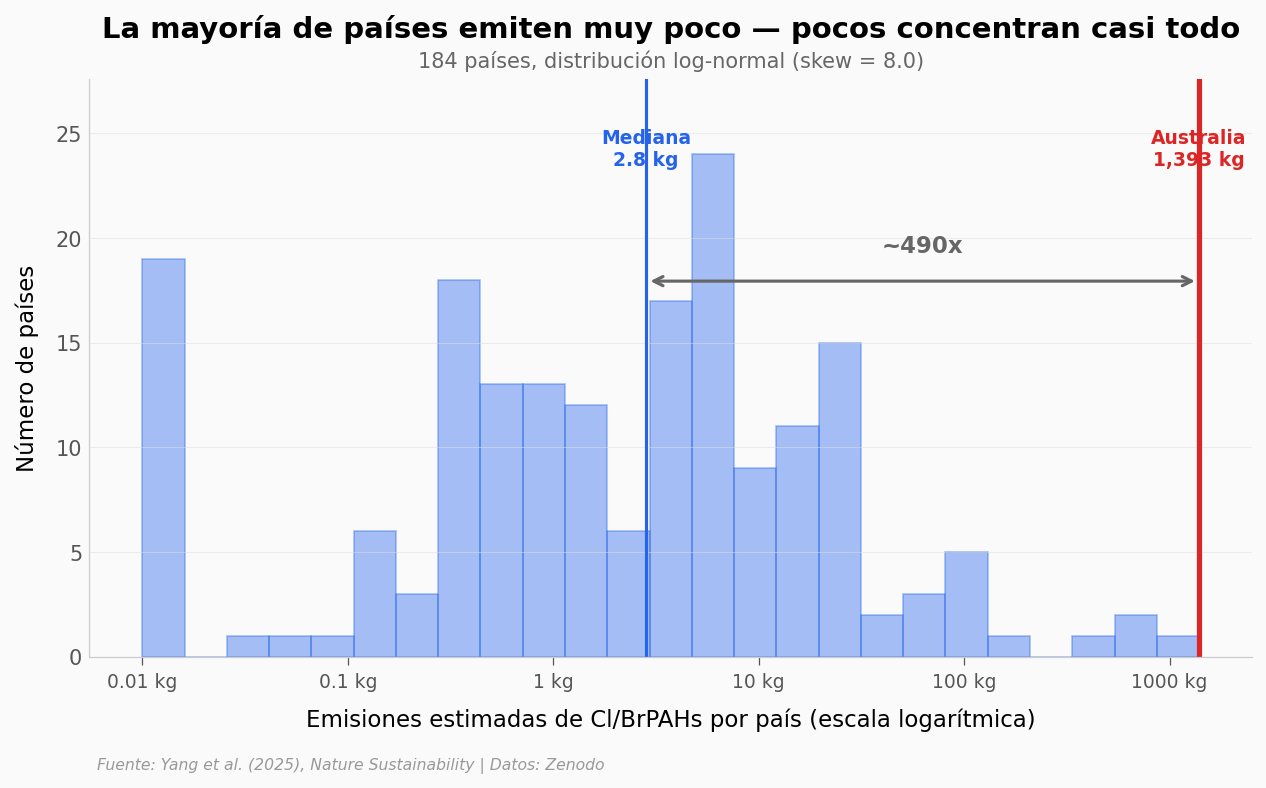

Top 3 países: 2,966 kg (58% del total)
Top 10 países: 3,998 kg (78% del total)
Los otros 174 países: 1,144 kg (22% del total)


In [5]:
# Distribución de emisiones por país — extremadamente concentrada
fig, ax = plt.subplots(figsize=(10, 5))

# Usar escala log porque la distribución es muy sesgada
emissions = df_pais['emision_total_kg']
log_emissions = np.log10(emissions.replace(0, np.nan).dropna())

n, bins, patches = ax.hist(log_emissions, bins=25, color=COLOR_DATOS, alpha=0.4,
                           edgecolor=COLOR_DATOS, linewidth=0.8)

# Mediana y Australia
median_log = np.log10(emissions.median())
australia_log = np.log10(emissions.max())

y_max = n.max() * 1.15
ax.set_ylim(0, y_max)

ax.axvline(x=median_log, color=COLOR_DATOS, linewidth=1.5)
ax.axvline(x=australia_log, color=COLOR_ALERTA, linewidth=2.5)

# Inline labels
ax.text(median_log, y_max * 0.85, f'Mediana\n{emissions.median():.1f} kg',
        ha='center', fontsize=9, color=COLOR_DATOS, fontweight='bold')
ax.text(australia_log, y_max * 0.85, f'Australia\n{emissions.max():,.0f} kg',
        ha='center', fontsize=9, color=COLOR_ALERTA, fontweight='bold')

# Flecha bidireccional
ax.annotate('', xy=(australia_log, y_max * 0.65), xytext=(median_log, y_max * 0.65),
            arrowprops=dict(arrowstyle='<->', color='#666666', lw=1.5))
ax.text((median_log + australia_log) / 2, y_max * 0.7, '~490x',
        ha='center', fontsize=11, fontweight='bold', color='#666666')

# Eje X con valores reales
tick_vals = [-2, -1, 0, 1, 2, 3]
ax.set_xticks(tick_vals)
ax.set_xticklabels([f'{10**t:g} kg' for t in tick_vals], fontsize=9)

ax.set_xlabel('Emisiones estimadas de Cl/BrPAHs por país (escala logarítmica)', fontsize=11)
ax.set_ylabel('Número de países', fontsize=11)
ax.set_title('La mayoría de países emiten muy poco — pocos concentran casi todo',
             fontsize=14, fontweight='bold', pad=20)
ax.text(0.5, 1.02, f'{N_PAISES} países, distribución log-normal (skew = {emissions.skew():.1f})',
        transform=ax.transAxes, fontsize=10, color='#666666', ha='center')

fig.text(0.13, -0.04, FUENTE, fontsize=7.5, color='#999999', style='italic')
plt.savefig('figuras/distribucion_emisiones.png', dpi=200, bbox_inches='tight')
plt.show()

# Estadísticas de concentración
top3 = emissions.nlargest(3).sum()
top10 = emissions.nlargest(10).sum()
total = emissions.sum()
print(f"Top 3 países: {top3:,.0f} kg ({top3/total*100:.0f}% del total)")
print(f"Top 10 países: {top10:,.0f} kg ({top10/total*100:.0f}% del total)")
print(f"Los otros 174 países: {total - top10:,.0f} kg ({(total - top10)/total*100:.0f}% del total)")

### Lo que los datos soportan

| Afirmación | ¿Soportada? | Detalle |
|------------|-------------|---------|
| Emisiones globales de ~5.143 kg | ✅ | Suma de 184 países = 5.142,5 kg. Estimación de modelo ML, no medición directa |
| IOS = 86,1% del total | ✅ | 3.788,5 kg. El 86,1% es del paper (11 sectores); en nuestros datos (8 sectores, 4.399,6 kg) da 86,1% consistente. Sobre el total por países (5.142,5 kg) sería 73,7% — la diferencia se debe a 3 sectores sin desglose individual |
| ClPAHs = 94,3% vs BrPAHs = 5,7% | ✅ | Datos de tipo de emisión coinciden exactamente con el abstract |
| Oceanía + Asia Oriental + Latinoamérica > 66% | ✅ | Regional CSV: 3.020 kg de 4.400 kg regionales = 68,6% (>66%). Nota: el CSV regional suma 4.400 kg (8 sectores), no 5.143 kg (total global). La diferencia son 3 sectores sin desglose regional |
| Australia lidera las emisiones globales | ✅ | 1.392,6 kg = 27,1% del total. También lidera per cápita (47,1 g/cap) |

> **Limitaciones:**
> - Los valores son **estimaciones** de un modelo XGBoost, no mediciones directas en chimenea. El paper usa "estimate" — no son hechos confirmados experimentalmente.
> - El modelo se entrenó con datos de emisión disponibles (81 países), y predijo los restantes 103 países.
> - Los factores de emisión (EF) provienen de literatura publicada, con alta variabilidad entre estudios.
> - Solo se consideraron emisiones industriales directas — no transporte, agricultura ni fuentes domésticas.

---

## Ahora tú

Tres preguntas para explorar:

1. **¿Cuál es el sector más tóxico por tonelada?** La sinterización emite más en total, pero su factor de emisión (1.330 mg/kt) es bajo comparado con la fundición de zinc (167.000 mg/kt). ¿Qué sector tiene el factor de emisión más alto para BrPAHs? *Pista: `df_ef.sort_values('ef_brpahs_mg_kt', ascending=False)`*

2. **¿Qué región tiene la mayor proporción de emisiones al aire vs partículas?** *Pista: `df_reg['ratio_stack_ipm'] = (df_reg.stack_gas_clpahs_kg + df_reg.stack_gas_brpahs_kg) / (df_reg.ipm_clpahs_kg + df_reg.ipm_brpahs_kg)`*

3. **¿Cómo se compara el per cápita de tu país con la mediana global?** Modifica la celda experimental para buscar tu país.

In [6]:
# --- EXPERIMENTA AQUÍ ---
# Busca un país y compara con la mediana global

pais_buscar = 'Colombia'  # Cambia por tu país

# Emisiones totales
match = df_pais[df_pais['pais'].str.contains(pais_buscar, case=False)]
if not match.empty:
    row = match.iloc[0]
    total = df_pais['emision_total_kg'].sum()
    rank = (df_pais['emision_total_kg'] > row['emision_total_kg']).sum() + 1
    print(f"🔍 {row['pais']}")
    print(f"   Emisiones totales: {row['emision_total_kg']:.2f} kg (puesto {rank} de {N_PAISES})")
    print(f"   Porcentaje global: {row['emision_total_kg']/total*100:.2f}%")
    print(f"   Mediana global: {df_pais['emision_total_kg'].median():.2f} kg")
    
    # Per cápita
    match_c = df_cap[df_cap['pais'].str.contains(pais_buscar, case=False)]
    if not match_c.empty:
        rc = match_c.iloc[0]
        rank_c = (df_cap['emision_g_per_capita'] > rc['emision_g_per_capita']).sum() + 1
        print(f"   Per cápita: {rc['emision_g_per_capita']:.4f} g/persona (puesto {rank_c})")
        print(f"   Mediana global per cápita: {df_cap['emision_g_per_capita'].median():.4f} g/persona")
        ratio = rc['emision_g_per_capita'] / df_cap['emision_g_per_capita'].median()
        print(f"   {'↑' if ratio > 1 else '↓'} {ratio:.1f}x la mediana")
else:
    print(f"País '{pais_buscar}' no encontrado. Prueba con el nombre en inglés.")
    print(f"Países disponibles (primeros 20): {sorted(df_pais['pais'].tolist())[:20]}")

🔍 Colombia
   Emisiones totales: 3.10 kg (puesto 89 de 184)
   Porcentaje global: 0.06%
   Mediana global: 2.83 kg
   Per cápita: 0.0635 g/persona (puesto 151)
   Mediana global per cápita: 0.1995 g/persona
   ↓ 0.3x la mediana


---

### Créditos

- **Paper:** Yang, Y. et al. (2025). Global industrial emissions of chlorinated and brominated polycyclic aromatic hydrocarbons. *Nature Sustainability*. DOI: [10.1038/s41893-025-01656-z](https://doi.org/10.1038/s41893-025-01656-z)
- **Datos:** [Zenodo — Dataset for Cl/Br-PAH Emission Calculations](https://doi.org/10.5281/zenodo.15869972)
- **Código del modelo:** [GitHub — XGBoost-Forecast-Model-of-XPAHs](https://github.com/123yangyueyao/XGBoost-Forecast-Model-of-XPAHs)
- **Licencia datos:** CC BY 4.0
- **Notebook:** [Ciencia a Mordiscos — El Lab](https://cienciaamordiscos.com)